In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv')

In [3]:
train['health_condition'].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [4]:
display(train.shape)
display(test.shape)

(690088, 15)

(295753, 14)

In [5]:
display(train.head())
display(test.head())

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [6]:
missing_summary = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing (%)": (train.isnull().mean() * 100).round(2)
})

# Keep only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

# Sort from highest to lowest percentage
missing_summary = missing_summary.sort_values(
    by="Missing (%)",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing (%)
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


In [7]:
missing_by_target = pd.DataFrame()

top_missing_cols = [
    "stress_level",
    "sleep_duration",
    "sleep_quality",
    "calorie_expenditure"
]

for col in top_missing_cols:
    train[f"{col}_missing"] = train[col].isna().astype(int)
    
for col in top_missing_cols:
    missing_by_target[col] = (
        train.groupby("health_condition")[f"{col}_missing"]
             .mean() * 100
    )

missing_by_target = missing_by_target.round(2)

display(missing_by_target)

,stress_level,sleep_duration,sleep_quality,calorie_expenditure
health_condition,,,,
at-risk,12.00,11.02,8.46,7.65
fit,11.96,10.94,8.53,7.70
unhealthy,11.99,10.97,8.31,7.69


In [8]:
id_col = "id"
target_col = "health_condition"

numeric_features = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
]

categorical_features = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
]

features = numeric_features + categorical_features

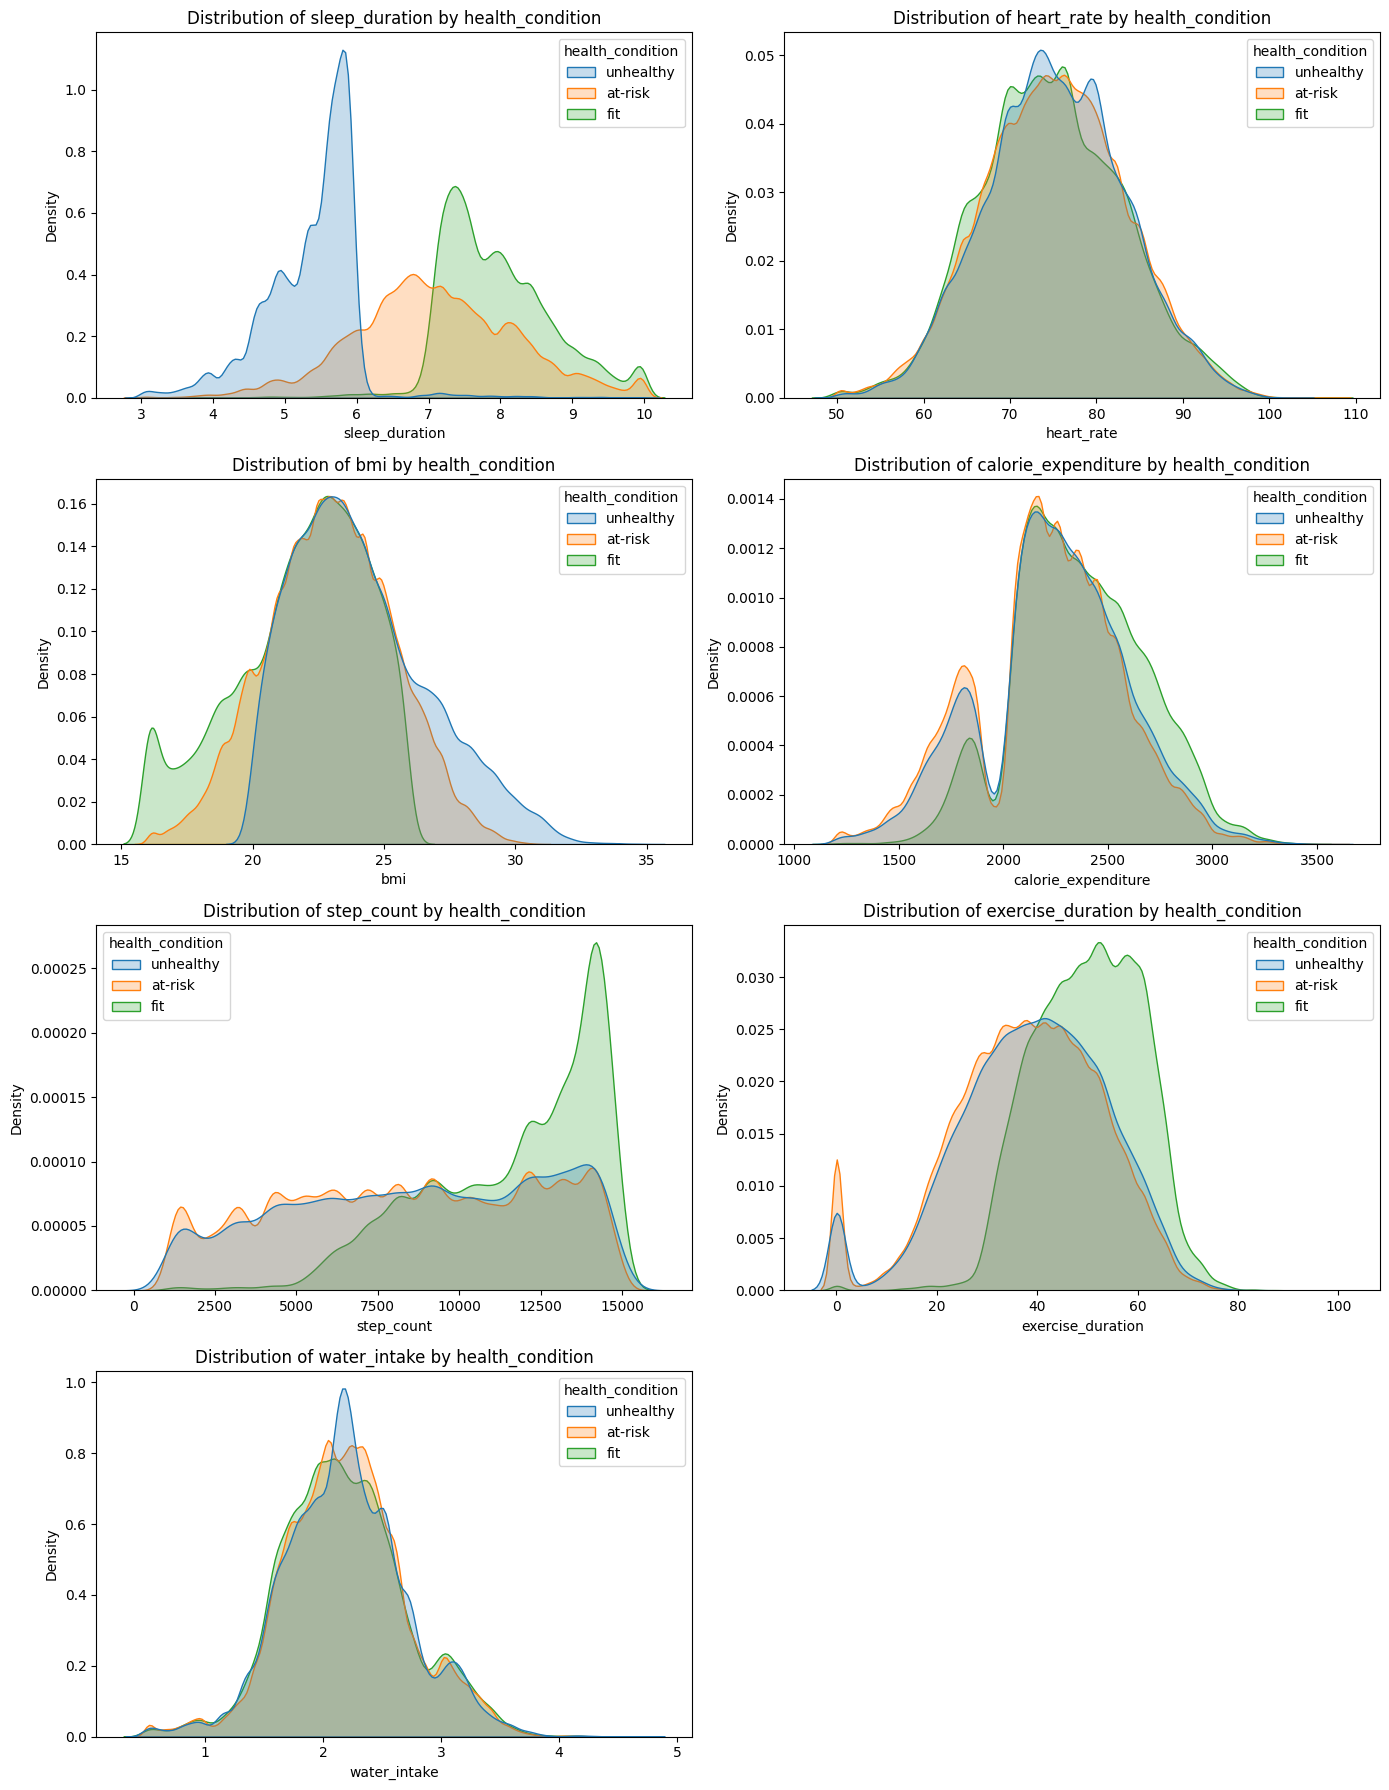

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.kdeplot(
        data=train,
        x=col,
        hue=target_col,
        fill=True,
        common_norm=False,   # important for imbalanced classes
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col} by {target_col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()



In [10]:
for col in categorical_features:
    print(f"\n{col}")
    print("Number of categories:", train[col].nunique(dropna=False))
    print(train[col].value_counts(dropna=False))


diet_type
Number of categories: 4
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

stress_level
Number of categories: 4
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

sleep_quality
Number of categories: 4
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

physical_activity_level
Number of categories: 4
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

smoking_alcohol
Number of categories: 4
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

gender
Number of categories: 4
gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64


In [11]:
for col in categorical_features:
    breakdown = pd.crosstab(
        train[col],
        train[target_col],
        normalize="index"
    ) * 100
    
    print(f"\nTarget breakdown by {col}")
    display(breakdown.round(2))


Target breakdown by diet_type


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30



Target breakdown by stress_level


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31



Target breakdown by sleep_quality


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03



Target breakdown by smoking_alcohol


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20



Target breakdown by gender


health_condition,at-risk,fit,unhealthy
gender,,,
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


In [12]:
combo_breakdown = (
    pd.crosstab(
        [train["stress_level"], train["physical_activity_level"]],
        train["health_condition"],
        normalize="index"
    ) * 100
).round(2)

display(combo_breakdown)

health_condition                      at-risk    fit  unhealthy
stress_level physical_activity_level                           
high         active                     70.05   0.43      29.53
             moderate                   72.08   0.35      27.58
             sedentary                  73.04   0.29      26.66
low          active                     41.83  57.88       0.28
             moderate                   99.49   0.25       0.26
             sedentary                  99.48   0.21       0.31
medium       active                     99.32   0.36       0.31
             moderate                   99.36   0.33       0.31
             sedentary                  99.50   0.22       0.28

In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from lightgbm import LGBMClassifier

SEED = 42  # controls randomness (so results are reproducible)
N_FOLDS = 5 # sets how many CV splits you'll use

# avoids accidentally modifying your original train/test DataFrames while you experiment
X = train[features].copy()
y_raw = train[target_col].copy()
X_test = test[features].copy()

# Fill missing numeric values with median in both train and test.
for col in numeric_features:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Fill missing categoricals with a placeholder, then label encode
for col in categorical_features:
    X[col] = X[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")
    # The reason it's fit on combined (train + test stacked together) rather than train alone: 
    # if a category value appears in test but never appeared in train, LabelEncoder would throw an error when it hits an unseen label.
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Encode the target itself
target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)   # at-risk / fit / unhealthy -> 0/1/2
print("Target classes:", list(target_le.classes_))

# Stratified CV loop
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(X), dtype=int) # holds one prediction per training row 
test_preds_proba = np.zeros((len(X_test), len(target_le.classes_))) # holds a running total of predicted probabilities for the actual test set (one column per class)
fold_scores = [] # collects each fold's score for later averaging

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    # A fresh model is created every fold (important — you don't want it remembering the previous fold's training)
    model = LGBMClassifier(
        n_estimators=500, # how many trees it builds
        learning_rate=0.05, # controls how much each tree corrects previous mistakes (smaller = more careful/slower learning)
        random_state=SEED, 
        class_weight="balanced",   # nudge the model to care about rare classes
        verbosity=-1,
    )
    model.fit(X_tr, y_tr)
    # -------------
    # After training, the model predicts on the held-out validation rows (X_val) — these are rows it never saw during this fold's training, so it's an honest test. 
    # Those predictions get stored in the right spots in oof_preds. 
    # Separately, the model also predicts on the real X_test set (the actual competition test data) — and this happens every fold,
    # with results averaged across all 5 folds (/ N_FOLDS), so your final test prediction is a blend of 5 slightly different models rather than relying on just one.
    # -----------
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds_proba += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.5f}")

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} "
      f"(+/- {np.std(fold_scores):.5f})")

# Confusion matrix on OOF predictions (the full picture, not just one fold)
cm = confusion_matrix(y, oof_preds)
cm_df = pd.DataFrame(cm, index=target_le.classes_, columns=target_le.classes_)
print("\nConfusion matrix (rows = actual, columns = predicted):")
print(cm_df)

# Build submission
# test_preds_proba has one probability per class per row
# argmax(axis=1) picks the class with the highest averaged probability for each row
# inverse_transform converts that back from 0/1/2 to the original text labels ("at-risk" etc.)
final_pred = target_le.inverse_transform(test_preds_proba.argmax(axis=1))

submission = sample_sub.copy()
submission[target_col] = final_pred
submission.to_csv("submission.csv", index=False)
print("\nSaved submission.csv")
submission.head()

Target classes: ['at-risk', 'fit', 'unhealthy']
Fold 0: balanced accuracy = 0.95026
Fold 1: balanced accuracy = 0.95148
Fold 2: balanced accuracy = 0.94890
Fold 3: balanced accuracy = 0.94916
Fold 4: balanced accuracy = 0.94763

Mean CV balanced accuracy: 0.94949 (+/- 0.00130)

Confusion matrix (rows = actual, columns = predicted):
           at-risk    fit  unhealthy
at-risk     554462  13722      24377
fit           1795  37790        218
unhealthy     1890    227      55607

Saved submission.csv


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [14]:
# ============================================================
# ERROR ANALYSIS: Understanding where the model gets confused
# ============================================================
# We already have from the baseline run:
#   y           -> true labels, encoded as 0/1/2
#   oof_preds   -> model's predicted labels (out-of-fold), same encoding
#   target_le   -> the LabelEncoder that maps 0/1/2 back to text labels
#   train       -> original dataframe (still has the raw, human-readable columns)

# ------------------------------------------------------------
# Step 1: Find which text label corresponds to which number
# ------------------------------------------------------------
# target_le.classes_ is ordered alphabetically by LabelEncoder,
# e.g. ['at-risk', 'fit', 'unhealthy'] -> 0, 1, 2
# We look this up dynamically instead of hardcoding 0/1/2,
# so the code doesn't silently break if the encoding order changes.
label_to_idx = {label: idx for idx, label in enumerate(target_le.classes_)}
at_risk_idx = label_to_idx["at-risk"]
fit_idx = label_to_idx["fit"]
unhealthy_idx = label_to_idx["unhealthy"]

# ------------------------------------------------------------
# Step 2: Build a working dataframe that lines up true label,
# predicted label, and the original raw features side by side.
# ------------------------------------------------------------
# train.reset_index(drop=True) ensures row positions match up
# exactly with the positions in y and oof_preds (both are plain
# numpy arrays indexed 0..N-1, not pandas-index-aware).
analysis_df = train.reset_index(drop=True).copy()
analysis_df["true_label"] = y
analysis_df["pred_label"] = oof_preds

# ------------------------------------------------------------
# Step 3: Isolate the two biggest error groups from the
# confusion matrix — rows that are ACTUALLY at-risk, but the
# model predicted something else.
# ------------------------------------------------------------

# Group A: true = at-risk, predicted = unhealthy  (biggest error cell)
mask_risk_as_unhealthy = (
    (analysis_df["true_label"] == at_risk_idx) &
    (analysis_df["pred_label"] == unhealthy_idx)
)
risk_as_unhealthy = analysis_df[mask_risk_as_unhealthy]

# Group B: true = at-risk, predicted = fit  (second biggest error cell)
mask_risk_as_fit = (
    (analysis_df["true_label"] == at_risk_idx) &
    (analysis_df["pred_label"] == fit_idx)
)
risk_as_fit = analysis_df[mask_risk_as_fit]

# Group C: true = at-risk, predicted = at-risk (correct) -- our baseline
# for comparison. We want to see how the misclassified groups differ
# from rows the model got RIGHT, not just look at them in isolation.
mask_risk_correct = (
    (analysis_df["true_label"] == at_risk_idx) &
    (analysis_df["pred_label"] == at_risk_idx)
)
risk_correct = analysis_df[mask_risk_correct]

print(f"Correctly classified at-risk rows: {len(risk_correct)}")
print(f"At-risk misclassified as unhealthy: {len(risk_as_unhealthy)}")
print(f"At-risk misclassified as fit:       {len(risk_as_fit)}")

# ------------------------------------------------------------
# Step 4: Compare stress_level distribution across the 3 groups.
# ------------------------------------------------------------
# normalize=True turns raw counts into percentages, so we can
# compare groups of very different sizes fairly (e.g. 24,374 vs
# 554,447 rows) -- otherwise the bigger group's counts would
# dominate any visual/number comparison.

print("\n--- stress_level breakdown ---")
print("\nCorrectly classified at-risk:")
print(risk_correct["stress_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as unhealthy:")
print(risk_as_unhealthy["stress_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as fit:")
print(risk_as_fit["stress_level"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# Step 5: Same comparison, but for physical_activity_level.
# ------------------------------------------------------------
print("\n--- physical_activity_level breakdown ---")
print("\nCorrectly classified at-risk:")
print(risk_correct["physical_activity_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as unhealthy:")
print(risk_as_unhealthy["physical_activity_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as fit:")
print(risk_as_fit["physical_activity_level"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# Step 6: Combine both features into one crosstab per group.
# This mirrors the 3x3 crosstab you did earlier during EDA --
# now we're asking "which stress/activity combinations is the
# model's mistake actually coming from?"
# ------------------------------------------------------------
print("\n--- stress_level x physical_activity_level (misclassified as unhealthy) ---")
print(pd.crosstab(
    risk_as_unhealthy["stress_level"],
    risk_as_unhealthy["physical_activity_level"],
    normalize="index"
) * 100)

print("\n--- stress_level x physical_activity_level (misclassified as fit) ---")
print(pd.crosstab(
    risk_as_fit["stress_level"],
    risk_as_fit["physical_activity_level"],
    normalize="index"
) * 100)

Correctly classified at-risk rows: 554462
At-risk misclassified as unhealthy: 24377
At-risk misclassified as fit:       13722

--- stress_level breakdown ---

Correctly classified at-risk:
stress_level
medium    51.642430
low       25.656813
high      22.700757
Name: proportion, dtype: float64

Misclassified as unhealthy:
stress_level
high      99.060645
medium     0.571128
low        0.368227
Name: proportion, dtype: float64

Misclassified as fit:
stress_level
low       96.875000
high       1.763393
medium     1.361607
Name: proportion, dtype: float64

--- physical_activity_level breakdown ---

Correctly classified at-risk:
physical_activity_level
sedentary    36.790307
moderate     36.707724
active       26.501969
Name: proportion, dtype: float64

Misclassified as unhealthy:
physical_activity_level
moderate     35.113641
sedentary    33.870757
active       31.015601
Name: proportion, dtype: float64

Misclassified as fit:
physical_activity_level
active       99.488311
moderate      0.


=== sleep_duration ===

Correctly classified at-risk:
count    506387.000000
mean          7.106925
std           1.129499
min           3.000000
25%           6.390000
50%           7.040000
75%           7.840000
max          10.000000
Name: sleep_duration, dtype: float64

Misclassified as unhealthy:
count    11469.000000
mean         5.548736
std          0.648205
min          3.000000
25%          5.250000
50%          5.690000
75%          5.940000
max          9.960000
Name: sleep_duration, dtype: float64

Misclassified as fit:
count    9397.000000
mean        7.860865
std         0.759565
min         3.950000
25%         7.260000
50%         7.710000
75%         8.300000
max        10.000000
Name: sleep_duration, dtype: float64

=== bmi ===

Correctly classified at-risk:
count    542765.000000
mean         22.935140
std           2.435189
min          16.010000
25%          21.260000
50%          22.950000
75%          24.640000
max          30.830000
Name: bmi, dtype: float64


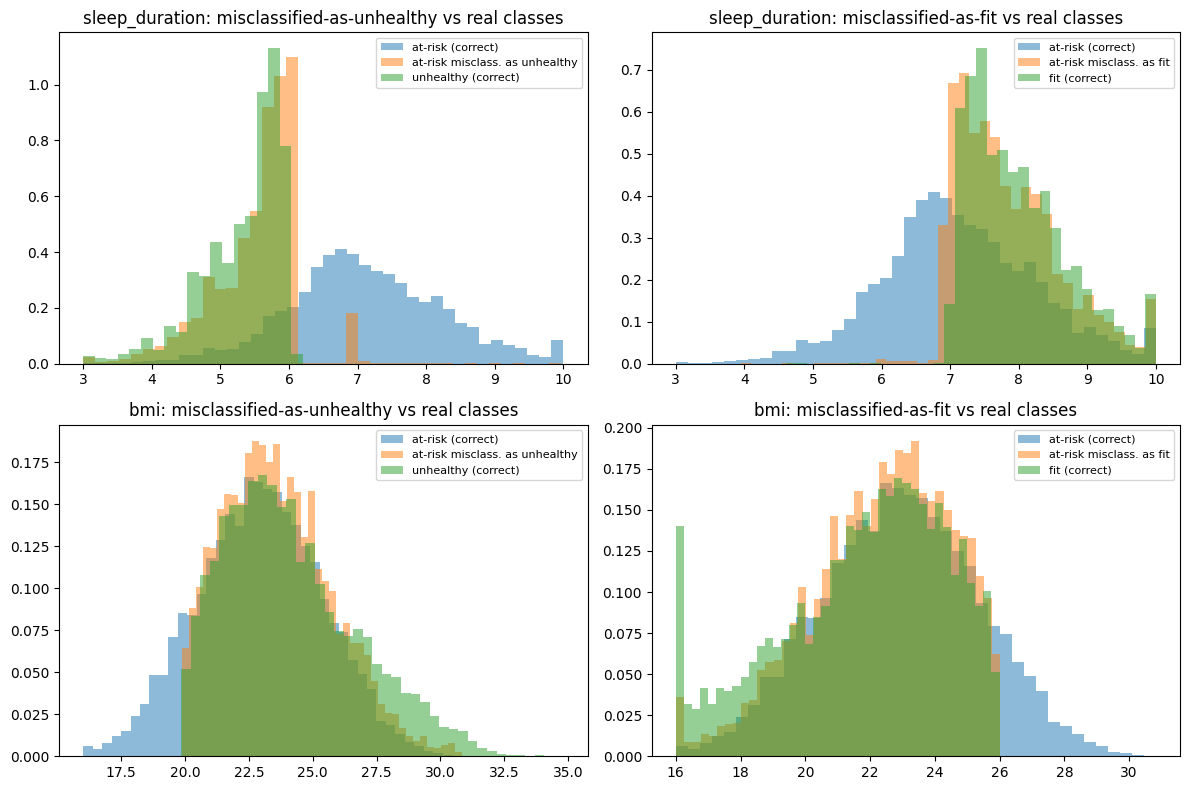

In [15]:
# ============================================================
# STEP 7: Check numeric features (sleep_duration, bmi) across
# the same three groups, to test the "label noise" theory.
# ============================================================
# Logic: if misclassified rows look just like a typical fit/unhealthy
# profile on these numeric features too (not just stress/activity),
# that reinforces the idea these are ambiguous/noisy labels rather
# than a gap in our feature set. If they look distinctly different
# from BOTH profiles, that's a more interesting signal worth digging into.

numeric_check_cols = ["sleep_duration", "bmi"]

for col in numeric_check_cols:
    print(f"\n=== {col} ===")

    # .describe() gives count, mean, std, min, quartiles, max --
    # a quick numeric summary per group, side by side.
    print("\nCorrectly classified at-risk:")
    print(risk_correct[col].describe())

    print("\nMisclassified as unhealthy:")
    print(risk_as_unhealthy[col].describe())

    print("\nMisclassified as fit:")
    print(risk_as_fit[col].describe())

# ------------------------------------------------------------
# STEP 8: For a fuller reference point, also pull the describe()
# stats for actual (correctly classified) fit and unhealthy rows.
# This gives us the "textbook profile" of each class to compare
# our misclassified at-risk rows against.
# ------------------------------------------------------------
mask_fit_correct = (analysis_df["true_label"] == fit_idx) & (analysis_df["pred_label"] == fit_idx)
fit_correct = analysis_df[mask_fit_correct]

mask_unhealthy_correct = (analysis_df["true_label"] == unhealthy_idx) & (analysis_df["pred_label"] == unhealthy_idx)
unhealthy_correct = analysis_df[mask_unhealthy_correct]

for col in numeric_check_cols:
    print(f"\n=== {col}: comparing misclassified at-risk vs. the REAL class profile ===")

    print("\nAt-risk misclassified as unhealthy (mean):", risk_as_unhealthy[col].mean())
    print("Actual unhealthy rows, correctly classified (mean):", unhealthy_correct[col].mean())

    print("\nAt-risk misclassified as fit (mean):", risk_as_fit[col].mean())
    print("Actual fit rows, correctly classified (mean):", fit_correct[col].mean())

# ------------------------------------------------------------
# STEP 9: Visualize it -- overlapping histograms are easier to
# read than a wall of describe() numbers, especially for spotting
# whether a misclassified group's distribution shape matches the
# real class it got confused with.
# ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: sleep_duration -- compare misclassified-as-unhealthy vs
# real unhealthy vs real at-risk, so we can see which one it resembles.
axes[0, 0].hist(risk_correct["sleep_duration"], bins=40, alpha=0.5, density=True, label="at-risk (correct)")
axes[0, 0].hist(risk_as_unhealthy["sleep_duration"], bins=40, alpha=0.5, density=True, label="at-risk misclass. as unhealthy")
axes[0, 0].hist(unhealthy_correct["sleep_duration"], bins=40, alpha=0.5, density=True, label="unhealthy (correct)")
axes[0, 0].set_title("sleep_duration: misclassified-as-unhealthy vs real classes")
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(risk_correct["sleep_duration"], bins=40, alpha=0.5, density=True, label="at-risk (correct)")
axes[0, 1].hist(risk_as_fit["sleep_duration"], bins=40, alpha=0.5, density=True, label="at-risk misclass. as fit")
axes[0, 1].hist(fit_correct["sleep_duration"], bins=40, alpha=0.5, density=True, label="fit (correct)")
axes[0, 1].set_title("sleep_duration: misclassified-as-fit vs real classes")
axes[0, 1].legend(fontsize=8)

# Row 2: same comparison for bmi
axes[1, 0].hist(risk_correct["bmi"], bins=40, alpha=0.5, density=True, label="at-risk (correct)")
axes[1, 0].hist(risk_as_unhealthy["bmi"], bins=40, alpha=0.5, density=True, label="at-risk misclass. as unhealthy")
axes[1, 0].hist(unhealthy_correct["bmi"], bins=40, alpha=0.5, density=True, label="unhealthy (correct)")
axes[1, 0].set_title("bmi: misclassified-as-unhealthy vs real classes")
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(risk_correct["bmi"], bins=40, alpha=0.5, density=True, label="at-risk (correct)")
axes[1, 1].hist(risk_as_fit["bmi"], bins=40, alpha=0.5, density=True, label="at-risk misclass. as fit")
axes[1, 1].hist(fit_correct["bmi"], bins=40, alpha=0.5, density=True, label="fit (correct)")
axes[1, 1].set_title("bmi: misclassified-as-fit vs real classes")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# EXPERIMENT: Baseline WITHOUT class_weight='balanced'
# ============================================================
# Why we're testing this: the confusion matrix showed the model
# over-predicting at-risk rows into the minority classes (fit/unhealthy).
# class_weight='balanced' tells the model to penalize mistakes on rare
# classes more heavily -- which could be PUSHING it to over-predict
# those classes more than the data actually supports. Removing it lets
# us see if that setting was helping or overcorrecting.
#
# Everything else stays identical to the baseline -- same folds, same
# features, same seed -- so any score difference is attributable ONLY
# to this one change.

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds_noweight = np.zeros(len(X), dtype=int)
test_preds_proba_noweight = np.zeros((len(X_test), len(target_le.classes_)))
fold_scores_noweight = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=SEED,
        # class_weight="balanced",   <-- removed for this experiment
        verbosity=-1,
    )
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val)
    oof_preds_noweight[val_idx] = val_pred
    test_preds_proba_noweight += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores_noweight.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.5f}")

print(f"\nMean CV balanced accuracy (no class_weight): "
      f"{np.mean(fold_scores_noweight):.5f} (+/- {np.std(fold_scores_noweight):.5f})")

# ------------------------------------------------------------
# Direct comparison against the original baseline score
# ------------------------------------------------------------
# We stored the original baseline's fold_scores earlier as `fold_scores`.
# This just puts both numbers side by side so the comparison is explicit
# rather than something you have to scroll up and remember.
print(f"\nBaseline (class_weight='balanced'):  {np.mean(fold_scores):.5f}")
print(f"No class_weight:                      {np.mean(fold_scores_noweight):.5f}")
print(f"Difference:                           {np.mean(fold_scores_noweight) - np.mean(fold_scores):.5f}")

# ------------------------------------------------------------
# New confusion matrix -- check whether the over-prediction into
# minority classes actually reduced, as we'd expect if class_weight
# was the cause.
# ------------------------------------------------------------
cm_noweight = confusion_matrix(y, oof_preds_noweight)
cm_noweight_df = pd.DataFrame(cm_noweight, index=target_le.classes_, columns=target_le.classes_)
print("\nConfusion matrix WITHOUT class_weight (rows = actual, columns = predicted):")
print(cm_noweight_df)

Fold 0: balanced accuracy = 0.87511
Fold 1: balanced accuracy = 0.87853
Fold 2: balanced accuracy = 0.87800
Fold 3: balanced accuracy = 0.87464
Fold 4: balanced accuracy = 0.87613

Mean CV balanced accuracy (no class_weight): 0.87648 (+/- 0.00154)

Baseline (class_weight='balanced'):  0.94949
No class_weight:                      0.87648
Difference:                           -0.07300

Confusion matrix WITHOUT class_weight (rows = actual, columns = predicted):
           at-risk    fit  unhealthy
at-risk     587735   2355       2471
fit           6619  33078        106
unhealthy    11091     76      46557


In [17]:
# # ============================================================
# # HYPERPARAMETER SWEEP: num_leaves x min_child_samples
# # ============================================================
# # Strategy: small targeted grid (not exhaustive), using early
# # stopping so we don't have to hand-pick n_estimators for each
# # combination. Everything else (folds, seed, features, class_weight)
# # stays identical to the baseline, so differences in score are
# # attributable only to these two knobs.

# from lightgbm import early_stopping, log_evaluation

# # ------------------------------------------------------------
# # Step 1: Define the small grid to test.
# # ------------------------------------------------------------
# # num_leaves: default is 31. We test a moderate step up in both
# # directions to see which way the model wants to move.
# # min_child_samples: default is 20. Given our minority class (fit,
# # ~40k rows), we test lower values (let it split on smaller groups)
# # and higher values (force more conservative splits) to see the effect.
# param_grid = [
#     {"num_leaves": 31,  "min_child_samples": 20},   # baseline settings, for reference
#     {"num_leaves": 63,  "min_child_samples": 20},
#     {"num_leaves": 127, "min_child_samples": 20},
#     {"num_leaves": 63,  "min_child_samples": 10},
#     {"num_leaves": 63,  "min_child_samples": 50},
# ]

# results = []

# # ------------------------------------------------------------
# # Step 2: For each param combination, run the full 5-fold CV
# # and record the mean balanced accuracy.
# # ------------------------------------------------------------
# for params in param_grid:
#     fold_scores_sweep = []

#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

#     for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
#         y_tr, y_val = y[tr_idx], y[val_idx]

#         model = LGBMClassifier(
#             n_estimators=2000,          # high ceiling -- early stopping will cut it short
#             learning_rate=0.05,
#             random_state=SEED,
#             class_weight="balanced",    # keep this -- we already proved it matters
#             num_leaves=params["num_leaves"],
#             min_child_samples=params["min_child_samples"],
#             verbosity=-1,
#         )

#         # early_stopping: stop adding trees once validation score
#         # hasn't improved for 50 rounds -- avoids overfitting AND
#         # avoids us having to guess the right n_estimators by hand.
#         # log_evaluation(0) silences the per-tree printout, since we
#         # only care about the final score, not the training log.
#         model.fit(
#             X_tr, y_tr,
#             eval_set=[(X_val, y_val)],
#             eval_metric="multi_logloss",
#             callbacks=[early_stopping(stopping_rounds=50), log_evaluation(0)],
#         )

#         val_pred = model.predict(X_val)
#         score = balanced_accuracy_score(y_val, val_pred)
#         fold_scores_sweep.append(score)

#     mean_score = np.mean(fold_scores_sweep)
#     std_score = np.std(fold_scores_sweep)

#     print(f"num_leaves={params['num_leaves']:>3}, "
#           f"min_child_samples={params['min_child_samples']:>3}  "
#           f"-> CV balanced accuracy = {mean_score:.5f} (+/- {std_score:.5f})")

#     results.append({
#         "num_leaves": params["num_leaves"],
#         "min_child_samples": params["min_child_samples"],
#         "mean_score": mean_score,
#         "std_score": std_score,
#     })

# # ------------------------------------------------------------
# # Step 3: Summarize all results in one sorted table, easiest
# # combination to compare at a glance.
# # ------------------------------------------------------------
# results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False)
# print("\n=== Sweep results, best to worst ===")
# print(results_df.to_string(index=False))

# print(f"\nOriginal baseline (num_leaves=31, min_child_samples=20): 0.94949")

In [18]:
# # ============================================================
# # CORRECTED HYPERPARAMETER SWEEP
# # ============================================================
# # Fixed n_estimators=500, no early stopping -- matches the exact
# # setup that produced your trusted 0.94949 baseline. This time any
# # score difference is attributable ONLY to num_leaves / min_child_samples,
# # not to a different stopping criterion.
# #
# # Based on the last sweep, num_leaves clearly wants to go DOWN, not up --
# # so this grid tests lower values than the default 31, plus reruns
# # min_child_samples variations fairly.

# param_grid = [
#     {"num_leaves": 31, "min_child_samples": 20},   # baseline, for a clean re-check
#     {"num_leaves": 20, "min_child_samples": 20},
#     {"num_leaves": 15, "min_child_samples": 20},
#     {"num_leaves": 31, "min_child_samples": 10},
#     {"num_leaves": 31, "min_child_samples": 50},
# ]

# results = []

# for params in param_grid:
#     fold_scores_sweep = []

#     skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

#     for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
#         y_tr, y_val = y[tr_idx], y[val_idx]

#         model = LGBMClassifier(
#             n_estimators=500,           # fixed, matches baseline exactly
#             learning_rate=0.05,
#             random_state=SEED,
#             class_weight="balanced",
#             num_leaves=params["num_leaves"],
#             min_child_samples=params["min_child_samples"],
#             verbosity=-1,
#         )
#         # No eval_set, no early stopping -- plain .fit(), same as baseline.
#         model.fit(X_tr, y_tr)

#         val_pred = model.predict(X_val)
#         score = balanced_accuracy_score(y_val, val_pred)
#         fold_scores_sweep.append(score)

#     mean_score = np.mean(fold_scores_sweep)
#     std_score = np.std(fold_scores_sweep)

#     print(f"num_leaves={params['num_leaves']:>3}, "
#           f"min_child_samples={params['min_child_samples']:>3}  "
#           f"-> CV balanced accuracy = {mean_score:.5f} (+/- {std_score:.5f})")

#     results.append({
#         "num_leaves": params["num_leaves"],
#         "min_child_samples": params["min_child_samples"],
#         "mean_score": mean_score,
#         "std_score": std_score,
#     })

# results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False)
# print("\n=== Sweep results, best to worst ===")
# print(results_df.to_string(index=False))
# print(f"\nOriginal baseline (num_leaves=31, min_child_samples=20): 0.94949")

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from lightgbm import LGBMClassifier

SEED = 42  # controls randomness (so results are reproducible)
N_FOLDS = 5 # sets how many CV splits you'll use

# avoids accidentally modifying your original train/test DataFrames while you experiment
X = train[features].copy()
y_raw = train[target_col].copy()
X_test = test[features].copy()

# Fill missing numeric values with median in both train and test.
for col in numeric_features:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Fill missing categoricals with a placeholder, then label encode
for col in categorical_features:
    X[col] = X[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")
    # The reason it's fit on combined (train + test stacked together) rather than train alone: 
    # if a category value appears in test but never appeared in train, LabelEncoder would throw an error when it hits an unseen label.
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Encode the target itself
target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)   # at-risk / fit / unhealthy -> 0/1/2
print("Target classes:", list(target_le.classes_))

# Stratified CV loop
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(X), dtype=int) # holds one prediction per training row 
test_preds_proba_param = np.zeros((len(X_test), len(target_le.classes_))) # holds a running total of predicted probabilities for the actual test set (one column per class)
fold_scores = [] # collects each fold's score for later averaging

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    # A fresh model is created every fold (important — you don't want it remembering the previous fold's training)
    # Updated model with your best sweep parameters
    model = LGBMClassifier(
        n_estimators=500, 
        learning_rate=0.05, 
        num_leaves=15,             # Added from sweep
        min_child_samples=20,      # Added from sweep
        random_state=SEED, 
        class_weight="balanced",   
        verbosity=-1,
    )
    model.fit(X_tr, y_tr)
    # -------------
    # After training, the model predicts on the held-out validation rows (X_val) — these are rows it never saw during this fold's training, so it's an honest test. 
    # Those predictions get stored in the right spots in oof_preds. 
    # Separately, the model also predicts on the real X_test set (the actual competition test data) — and this happens every fold,
    # with results averaged across all 5 folds (/ N_FOLDS), so your final test prediction is a blend of 5 slightly different models rather than relying on just one.
    # -----------
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds_proba_param += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.5f}")

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} "
      f"(+/- {np.std(fold_scores):.5f})")

# Confusion matrix on OOF predictions (the full picture, not just one fold)
cm = confusion_matrix(y, oof_preds)
cm_df = pd.DataFrame(cm, index=target_le.classes_, columns=target_le.classes_)
print("\nConfusion matrix (rows = actual, columns = predicted):")
print(cm_df)

# Build submission
# test_preds_proba has one probability per class per row
# argmax(axis=1) picks the class with the highest averaged probability for each row
# inverse_transform converts that back from 0/1/2 to the original text labels ("at-risk" etc.)
final_pred_param = target_le.inverse_transform(test_preds_proba_param.argmax(axis=1))

submission_param = sample_sub.copy()
submission_param[target_col] = final_pred_param
submission_param.to_csv("submission_param.csv", index=False)
print("\nSaved submission_param.csv")
submission.head()

Target classes: ['at-risk', 'fit', 'unhealthy']
Fold 0: balanced accuracy = 0.95035
Fold 1: balanced accuracy = 0.95158
Fold 2: balanced accuracy = 0.94879
Fold 3: balanced accuracy = 0.94918
Fold 4: balanced accuracy = 0.94800

Mean CV balanced accuracy: 0.94958 (+/- 0.00126)

Confusion matrix (rows = actual, columns = predicted):
           at-risk    fit  unhealthy
at-risk     553250  13985      25326
fit           1772  37816        215
unhealthy     1776    244      55704

Saved submission_param.csv


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [20]:
# ============================================================
# CATBOOST BASELINE — same CV structure as LightGBM, but letting
# CatBoost handle categoricals natively instead of label encoding.
# ============================================================
from catboost import CatBoostClassifier

# ------------------------------------------------------------
# Step 1: Rebuild X from scratch, WITHOUT label-encoding the
# categorical columns this time -- CatBoost wants the raw text.
# (Numeric preprocessing stays the same: median fill.)
# ------------------------------------------------------------
X_cb = train[features].copy()
X_test_cb = test[features].copy()

for col in numeric_features:
    median_val = X_cb[col].median()
    X_cb[col] = X_cb[col].fillna(median_val)
    X_test_cb[col] = X_test_cb[col].fillna(median_val)

# For categoricals: just fill missing with a placeholder string,
# same idea as before -- but NO LabelEncoder this time. CatBoost
# needs the columns to stay as strings/objects.
for col in categorical_features:
    X_cb[col] = X_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

# CatBoost needs to know WHICH columns are categorical, by name
# or position. We pass the column names directly here.
cat_features = categorical_features

# Target (y) is reused as-is from before -- already encoded 0/1/2,
# CatBoost is fine with integer-encoded multiclass targets.

# ------------------------------------------------------------
# Step 2: Same CV loop pattern as the LightGBM baseline.
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds_cb = np.zeros(len(X_cb), dtype=int)
test_preds_proba_cb = np.zeros((len(X_test_cb), len(target_le.classes_)))
fold_scores_cb = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cb, y)):
    X_tr, X_val = X_cb.iloc[tr_idx], X_cb.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = CatBoostClassifier(
        iterations=500,              # roughly matches n_estimators=500 from LightGBM
        learning_rate=0.05,          # same as LightGBM, for a fair comparison
        random_seed=SEED,
        auto_class_weights="Balanced",   # CatBoost's equivalent of class_weight='balanced'
        cat_features=cat_features,       # tells CatBoost which columns to treat categorically
        verbose=False,                   # suppress the per-iteration training log
    )

    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val).flatten()   # CatBoost returns a 2D array; flatten to 1D
    oof_preds_cb[val_idx] = val_pred
    test_preds_proba_cb += model.predict_proba(X_test_cb) / N_FOLDS

    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores_cb.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.5f}")

print(f"\nMean CV balanced accuracy (CatBoost): "
      f"{np.mean(fold_scores_cb):.5f} (+/- {np.std(fold_scores_cb):.5f})")
print(f"LightGBM baseline for comparison:      0.94949")

# ------------------------------------------------------------
# Step 3: Confusion matrix, same format as before, for direct
# side-by-side comparison with the LightGBM one.
# ------------------------------------------------------------
cm_cb = confusion_matrix(y, oof_preds_cb)
cm_cb_df = pd.DataFrame(cm_cb, index=target_le.classes_, columns=target_le.classes_)
print("\nConfusion matrix (CatBoost, rows = actual, columns = predicted):")
print(cm_cb_df)

# ------------------------------------------------------------
# Step 4: The key diagnostic -- do LightGBM and CatBoost make
# the SAME mistakes, or DIFFERENT ones? This tells us whether
# ensembling them is actually likely to help.
# ------------------------------------------------------------
# agreement_rate: how often do the two models predict the same class?
agreement_rate = (oof_preds == oof_preds_cb).mean()
print(f"\nLightGBM vs CatBoost prediction agreement rate: {agreement_rate:.4f}")

# Among rows where LightGBM was WRONG, how often was CatBoost RIGHT?
# If this is high, CatBoost is "rescuing" errors LightGBM makes --
# a strong sign ensembling will help.
lgbm_wrong = (oof_preds != y)
catboost_rescues = (oof_preds_cb[lgbm_wrong] == y[lgbm_wrong]).mean()
print(f"Of rows where LightGBM was wrong, CatBoost got right: {catboost_rescues:.4f}")

# And the reverse -- among rows where CatBoost was wrong, how often
# was LightGBM right?
catboost_wrong = (oof_preds_cb != y)
lgbm_rescues = (oof_preds[catboost_wrong] == y[catboost_wrong]).mean()
print(f"Of rows where CatBoost was wrong, LightGBM got right: {lgbm_rescues:.4f}")

final_pred_cb = target_le.inverse_transform(test_preds_proba_cb.argmax(axis=1))

submission_cb = sample_sub.copy()
submission_cb[target_col] = final_pred_cb
submission_cb.to_csv("submission_cb.csv", index=False)
print("\nSaved submission_cb.csv")
submission.head()

Fold 0: balanced accuracy = 0.94962
Fold 1: balanced accuracy = 0.95099
Fold 2: balanced accuracy = 0.94855
Fold 3: balanced accuracy = 0.94894
Fold 4: balanced accuracy = 0.94748

Mean CV balanced accuracy (CatBoost): 0.94912 (+/- 0.00116)
LightGBM baseline for comparison:      0.94949

Confusion matrix (CatBoost, rows = actual, columns = predicted):
           at-risk    fit  unhealthy
at-risk     553139  14234      25188
fit           1770  37832        201
unhealthy     1834    279      55611

LightGBM vs CatBoost prediction agreement rate: 0.9954
Of rows where LightGBM was wrong, CatBoost got right: 0.0325
Of rows where CatBoost was wrong, LightGBM got right: 0.0366

Saved submission_cb.csv


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [21]:
# ============================================================
# FINAL SUBMISSION: Ensemble of LightGBM + CatBoost
# ============================================================
# Both models predict probabilities per class for every test row.
# We average the two probability arrays together, then pick the
# class with the highest averaged probability as the final prediction.
#
# Why average probabilities rather than average hard predictions:
# averaging probabilities lets a model's CONFIDENCE matter, not just
# its final vote. If LightGBM is 90% sure of "at-risk" and CatBoost
# is 51% sure of "unhealthy", the averaged probability correctly
# leans toward "at-risk" -- a simple majority vote on hard labels
# would lose that nuance.

# ------------------------------------------------------------
# Step 1: Sanity check both probability arrays line up correctly
# ------------------------------------------------------------
# Both should be shape (n_test_rows, 3) -- one probability per class,
# per row. If these shapes don't match, something upstream is wrong
# and we should NOT proceed to average them.
print("LightGBM test_preds_proba shape:", test_preds_proba.shape)
print("CatBoost test_preds_proba_cb shape:", test_preds_proba_cb.shape)
assert test_preds_proba.shape == test_preds_proba_cb.shape, \
    "Shape mismatch -- check that both models predicted on the same test set"

# ------------------------------------------------------------
# Step 2: Average the two probability arrays.
# ------------------------------------------------------------
# Simple 50/50 average -- reasonable default given the two models'
# CV scores were nearly identical (0.94949 vs 0.94912). If one model
# had clearly outperformed the other, a weighted average favoring
# the stronger model would make sense instead -- not needed here.
ensemble_proba = (test_preds_proba + test_preds_proba_cb) / 2

# ------------------------------------------------------------
# Step 3: Convert averaged probabilities into final class predictions.
# ------------------------------------------------------------
# argmax picks the column (class) with the highest averaged
# probability for each row. inverse_transform converts the
# 0/1/2 encoding back to the original text labels.
final_pred_ensemble = target_le.inverse_transform(ensemble_proba.argmax(axis=1))

# ------------------------------------------------------------
# Step 4: Quick sanity check -- compare the ensemble's predicted
# class distribution against the training set's true distribution.
# They won't match exactly, but wildly different proportions here
# would suggest something's gone wrong (e.g. a column mismatch).
# ------------------------------------------------------------
print("\nEnsemble predicted class distribution (test set):")
print(pd.Series(final_pred_ensemble).value_counts(normalize=True) * 100)

print("\nTrue class distribution (train set), for comparison:")
print(train["health_condition"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# Step 5: Build and save the submission file.
# ------------------------------------------------------------
submission_ensemble = sample_sub.copy()
submission_ensemble[target_col] = final_pred_ensemble
submission_ensemble.to_csv("submission_ensemble.csv", index=False)

print("\nSaved submission_ensemble.csv")
print(submission_ensemble.head())

LightGBM test_preds_proba shape: (295753, 3)
CatBoost test_preds_proba_cb shape: (295753, 3)

Ensemble predicted class distribution (test set):
at-risk      80.988866
unhealthy    11.614760
fit           7.396375
Name: proportion, dtype: float64

True class distribution (train set), for comparison:
health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64

Saved submission_ensemble.csv
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy


In [22]:
n_changed = (final_pred_ensemble != final_pred).sum()
print(f"\nRows where ensemble prediction differs from LightGBM-only: {n_changed} "
      f"({n_changed / len(final_pred_ensemble) * 100:.2f}%)")


Rows where ensemble prediction differs from LightGBM-only: 622 (0.21%)
